<a href="https://colab.research.google.com/github/davontaew04-a11y/tensorflow/blob/main/Davontae%20Williams%20project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================================
# 1.1 VERIFY PYTHON & JUPYTER
# =========================================================
!python --version

Python 3.12.13


In [ ]:
# =========================================================
# 1.2 INSTALL REQUIRED LIBRARIES
# =========================================================

!pip install datasets pandas matplotlib seaborn pyarrow

import datasets
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow

In [ ]:
# =========================================================
# 2.2 LOAD REVIEWS DATASET
# =========================================================

from datasets import load_dataset
from huggingface_hub import list_repo_files, hf_hub_download
import pandas as pd

# List dataset files
files = list_repo_files(
    "McAuley-Lab/Amazon-Reviews-2023",
    repo_type="dataset"
)

print("Sample files:", files[:10])  # DEBUG

# Flexible filter
parquet_files = [f for f in files if f.endswith(".parquet")]

if len(parquet_files) == 0:
    raise ValueError("Still no parquet files found. Check file list above.")

print("Downloading:", parquet_files[0])

# Download
local_file = hf_hub_download(
    repo_id="McAuley-Lab/Amazon-Reviews-2023",
    filename=parquet_files[0],
    repo_type="dataset"
)

# Load
dataset = load_dataset("parquet", data_files=local_file, split="train")

# First 100 rows

reviews_df = dataset.select(range(100)).to_pandas()

print("Rows collected:", len(reviews_df))
print(reviews_df.head())



Sample files: ['.gitattributes', 'Amazon-Reviews-2023.py', 'README.md', 'all_categories.txt', 'asin2category.json', 'benchmark/0core/last_out/All_Beauty.test.csv', 'benchmark/0core/last_out/All_Beauty.train.csv', 'benchmark/0core/last_out/All_Beauty.valid.csv', 'benchmark/0core/last_out/Amazon_Fashion.test.csv', 'benchmark/0core/last_out/Amazon_Fashion.train.csv']
Downloading: raw_meta_All_Beauty/full-00000-of-00001.parquet
Rows collected: 100
  main_category                                              title  \
0    All Beauty  Howard LC0008 Leather Conditioner, 8-Ounce (4-...   
1    All Beauty  Yes to Tomatoes Detoxifying Charcoal Cleanser ...   
2    All Beauty   Eye Patch Black Adult with Tie Band (6 Per Pack)   
3    All Beauty  Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...   
4    All Beauty  Precision Plunger Bars for Cartridge Grips – 9...   

   average_rating  rating_number  \
0             4.8             10   
1             4.5              3   
2             4.4      

In [ ]:
# =========================================================
# 2.3 INSPECT DATA
# =========================================================
dataset = load_dataset("parquet", data_files=local_file, split="train")

df = dataset.select(range(100)).to_pandas()

reviews_df = df
reviews_df.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",4.8,10,[],[],None,"{'hi_res': [None, 'https://m.media-amazon.com/...","{'title': [], 'url': [], 'user_id': []}",Howard Products,[],"{""Package Dimensions"": ""7.1 x 5.5 x 3 inches; ...",B01CUPMQZE,None,None,None
1,All Beauty,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,4.5,3,[],[],None,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': [], 'url': [], 'user_id': []}",Yes To,[],"{""Item Form"": ""Powder"", ""Skin Type"": ""Acne Pro...",B076WQZGPM,None,None,None
2,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,[],[],None,"{'hi_res': [None, None], 'large': ['https://m....","{'title': [], 'url': [], 'user_id': []}",Levine Health Products,[],"{""Manufacturer"": ""Levine Health Products""}",B000B658RI,None,None,None
3,All Beauty,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...",3.1,102,[],[],None,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': [], 'url': [], 'user_id': []}",Cherioll,[],"{""Brand"": ""Cherioll"", ""Item Form"": ""Powder"", ""...",B088FKY3VD,None,None,None
4,All Beauty,Precision Plunger Bars for Cartridge Grips – 9...,4.3,7,"[Material: 304 Stainless Steel; Brass tip, Len...",[The Precision Plunger Bars are designed to wo...,None,"{'hi_res': [None], 'large': ['https://m.media-...","{'title': [], 'url': [], 'user_id': []}",Precision,[],"{""UPC"": ""644287689178""}",B07NGFDN6G,None,None,None


In [ ]:
# =========================================================
# 2.4 CUSTOM DISPLAY SETTINGS
# =========================================================

items_To_Print = 10

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

reviews_df.head(Items_To_Print)

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-Pack)",4.8,10,[],[],None,"{'hi_res': [None, 'https://m.media-amazon.com/images/I/71i77AuI9xL._SL1500_.jpg'], 'large': ['https://m.media-amazon.com/images/I/41qfjSfqNyL.jpg', 'https://m.media-amazon.com/images/I/41w2yznfuZL.jpg'], 'thumb': ['https://m.media-amazon.com/images/I/41qfjSfqNyL._SS40_.jpg', 'https://m.media-amazon.com/images/I/41w2yznfuZL._SS40_.jpg'], 'variant': ['MAIN', 'PT01']}","{'title': [], 'url': [], 'user_id': []}",Howard Products,[],"{""Package Dimensions"": ""7.1 x 5.5 x 3 inches; 2.38 Pounds"", ""UPC"": ""617390882781""}",B01CUPMQZE,None,None,None
1,All Beauty,"Yes to Tomatoes Detoxifying Charcoal Cleanser (Pack of 2) with Charcoal Powder, Tomato Fruit Extract, and Gingko Biloba Leaf Extract, 5 fl. oz.",4.5,3,[],[],None,"{'hi_res': ['https://m.media-amazon.com/images/I/71g1lP0pMbL._SL1500_.jpg', 'https://m.media-amazon.com/images/I/81OqvR94isL._SL1500_.jpg'], 'large': ['https://m.media-amazon.com/images/I/41b+11d5igL.jpg', 'https://m.media-amazon.com/images/I/41j2ocUzCtL.jpg'], 'thumb': ['https://m.media-amazon.com/images/I/41b+11d5igL._SS40_.jpg', 'https://m.media-amazon.com/images/I/41j2ocUzCtL._SS40_.jpg'], 'variant': ['MAIN', 'PT01']}","{'title': [], 'url': [], 'user_id': []}",Yes To,[],"{""Item Form"": ""Powder"", ""Skin Type"": ""Acne Prone"", ""Brand"": ""Yes To"", ""Age Range (Description)"": ""Adult"", ""Unit Count"": ""10 Fl Oz"", ""Is Discontinued By Manufacturer"": ""No"", ""Item model number"": ""SG_B076WQZGPM_US"", ""UPC"": ""653801351125"", ""Manufacturer"": ""Yes to Tomatoes""}",B076WQZGPM,None,None,None
2,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,[],[],None,"{'hi_res': [None, None], 'large': ['https://m.media-amazon.com/images/I/31bz+uqzWCL.jpg', 'https://m.media-amazon.com/images/I/31bz+uqzWCL.jpg'], 'thumb': ['https://m.media-amazon.com/images/I/31bz+uqzWCL._SS40_.jpg', 'https://m.media-amazon.com/images/I/31bz+uqzWCL._SS40_.jpg'], 'variant': ['MAIN', 'PT01']}","{'title': [], 'url': [], 'user_id': []}",Levine Health Products,[],"{""Manufacturer"": ""Levine Health Products""}",B000B658RI,None,None,None
3,All Beauty,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4D Imitation Eyebrow Tattoos, 4D Hair-like Authentic Eyebrows Waterproof Long Lasting for Woman & Man Makeup Tool",3.1,102,[],[],None,"{'hi_res': ['https://m.media-amazon.com/images/I/71GJhXQGvyL._SL1500_.jpg', 'https://m.media-amazon.com/images/I/61NS1lONhzL._SL1001_.jpg', 'https://m.media-amazon.com/images/I/61lcwXtw3ZL._SL1001_.jpg', 'https://m.media-amazon.com/images/I/61G-iZeX-LL._SL1001_.jpg', 'https://m.media-amazon.com/images/I/618BBBsAQrL._SL1001_.jpg', 'https://m.media-amazon.com/images/I/61iomcZjbAL._SL1001_.jpg', 'https://m.media-amazon.com/images/I/61m-71vCbCL._SL1001_.jpg'], 'large': ['https://m.media-amazon.com/images/I/515iwxdKS1L.jpg', 'https://m.media-amazon.com/images/I/51ALSVnGDML.jpg', 'https://m.media-amazon.com/images/I/51GvPall-ML.jpg', 'https://m.media-amazon.com/images/I/51JFEUql-KL.jpg', 'https://m.media-amazon.com/images/I/414rIT4vNAL.jpg', 'https://m.media-amazon.com/images/I/41JVLUdtYaL.jpg', 'https://m.media-amazon.com/images/I/51Vxn6nVrVL.jpg'], 'thumb': ['https://m.media-amazon.com/images/I/515iwxdKS1L._SS40_.jpg', 'https://m.media-amazon.com/images/I/51ALSVnGDML._SS40_.jpg', 'https://m.media-amazon.com/images/I/51GvPall-ML._SS40_.jpg', 'https://m.media-amazon.com/images/I/51JFEUql-KL._SS40_.jpg', 'https://m.media-amazon.com/images/I/414rIT4vNAL._SS40_.jpg', 'https://m.media-amazon.com/images/I/41JVLUdtYaL._SS40_.jpg', 'https://m.media-amazon.com/images/I/51Vxn6nVrVL._SS40_.jpg'], 'variant': ['MAIN', 'PT01', 'PT02', 'PT03', 'PT04', 'PT05', 'PT06']}","{'title': [], 'url': [], 'user_id': []}",Cherioll,[],"{""Brand"": ""Cherioll"", ""Item Form"": ""Powder"", ""Fi

In [ ]:
# =========================================================
# (3.1) LOAD METADATA DATASET
# =========================================================

from datasets import load_dataset
import pandas as pd

metadata_dataset = load_dataset(
    "parquet",
    data_files="hf://datasets/McAuley-Lab/Amazon-Reviews-2023/raw_meta_All_Beauty/*.parquet",
    split="train[:100]"
)

item_metadata_df = pd.DataFrame(metadata_dataset)
metadata_df = item_metadata_df

print("Metadata loaded")
metadata_df.head()

Generating train split: 0 examples [00:00, ? examples/s]

Metadata loaded


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-Pack)",4.8,10,[],[],None,"{'hi_res': [None, 'https://m.media-amazon.com/images/I/71i77AuI9xL._SL1500_.jpg'], 'large': ['https://m.media-amazon.com/images/I/41qfjSfqNyL.jpg', 'https://m.media-amazon.com/images/I/41w2yznfuZL.jpg'], 'thumb': ['https://m.media-amazon.com/images/I/41qfjSfqNyL._SS40_.jpg', 'https://m.media-amazon.com/images/I/41w2yznfuZL._SS40_.jpg'], 'variant': ['MAIN', 'PT01']}","{'title': [], 'url': [], 'user_id': []}",Howard Products,[],"{""Package Dimensions"": ""7.1 x 5.5 x 3 inches; 2.38 Pounds"", ""UPC"": ""617390882781""}",B01CUPMQZE,None,None,None
1,All Beauty,"Yes to Tomatoes Detoxifying Charcoal Cleanser (Pack of 2) with Charcoal Powder, Tomato Fruit Extract, and Gingko Biloba Leaf Extract, 5 fl. oz.",4.5,3,[],[],None,"{'hi_res': ['https://m.media-amazon.com/images/I/71g1lP0pMbL._SL1500_.jpg', 'https://m.media-amazon.com/images/I/81OqvR94isL._SL1500_.jpg'], 'large': ['https://m.media-amazon.com/images/I/41b+11d5igL.jpg', 'https://m.media-amazon.com/images/I/41j2ocUzCtL.jpg'], 'thumb': ['https://m.media-amazon.com/images/I/41b+11d5igL._SS40_.jpg', 'https://m.media-amazon.com/images/I/41j2ocUzCtL._SS40_.jpg'], 'variant': ['MAIN', 'PT01']}","{'title': [], 'url': [], 'user_id': []}",Yes To,[],"{""Item Form"": ""Powder"", ""Skin Type"": ""Acne Prone"", ""Brand"": ""Yes To"", ""Age Range (Description)"": ""Adult"", ""Unit Count"": ""10 Fl Oz"", ""Is Discontinued By Manufacturer"": ""No"", ""Item model number"": ""SG_B076WQZGPM_US"", ""UPC"": ""653801351125"", ""Manufacturer"": ""Yes to Tomatoes""}",B076WQZGPM,None,None,None
2,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,[],[],None,"{'hi_res': [None, None], 'large': ['https://m.media-amazon.com/images/I/31bz+uqzWCL.jpg', 'https://m.media-amazon.com/images/I/31bz+uqzWCL.jpg'], 'thumb': ['https://m.media-amazon.com/images/I/31bz+uqzWCL._SS40_.jpg', 'https://m.media-amazon.com/images/I/31bz+uqzWCL._SS40_.jpg'], 'variant': ['MAIN', 'PT01']}","{'title': [], 'url': [], 'user_id': []}",Levine Health Products,[],"{""Manufacturer"": ""Levine Health Products""}",B000B658RI,None,None,None
3,All Beauty,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4D Imitation Eyebrow Tattoos, 4D Hair-like Authentic Eyebrows Waterproof Long Lasting for Woman & Man Makeup Tool",3.1,102,[],[],None,"{'hi_res': ['https://m.media-amazon.com/images/I/71GJhXQGvyL._SL1500_.jpg', 'https://m.media-amazon.com/images/I/61NS1lONhzL._SL1001_.jpg', 'https://m.media-amazon.com/images/I/61lcwXtw3ZL._SL1001_.jpg', 'https://m.media-amazon.com/images/I/61G-iZeX-LL._SL1001_.jpg', 'https://m.media-amazon.com/images/I/618BBBsAQrL._SL1001_.jpg', 'https://m.media-amazon.com/images/I/61iomcZjbAL._SL1001_.jpg', 'https://m.media-amazon.com/images/I/61m-71vCbCL._SL1001_.jpg'], 'large': ['https://m.media-amazon.com/images/I/515iwxdKS1L.jpg', 'https://m.media-amazon.com/images/I/51ALSVnGDML.jpg', 'https://m.media-amazon.com/images/I/51GvPall-ML.jpg', 'https://m.media-amazon.com/images/I/51JFEUql-KL.jpg', 'https://m.media-amazon.com/images/I/414rIT4vNAL.jpg', 'https://m.media-amazon.com/images/I/41JVLUdtYaL.jpg', 'https://m.media-amazon.com/images/I/51Vxn6nVrVL.jpg'], 'thumb': ['https://m.media-amazon.com/images/I/515iwxdKS1L._SS40_.jpg', 'https://m.media-amazon.com/images/I/51ALSVnGDML._SS40_.jpg', 'https://m.media-amazon.com/images/I/51GvPall-ML._SS40_.jpg', 'https://m.media-amazon.com/images/I/51JFEUql-KL._SS40_.jpg', 'https://m.media-amazon.com/images/I/414rIT4vNAL._SS40_.jpg', 'https://m.media-amazon.com/images/I/41JVLUdtYaL._SS40_.jpg', 'https://m.media-amazon.com/images/I/51Vxn6nVrVL._SS40_.jpg'], 'variant': ['MAIN', 'PT01', 'PT02', 'PT03', 'PT04', 'PT05', 'PT06']}","{'title': [], 'url': [], 'user_id': []}",Cherioll,[],"{""Brand"": ""Cherioll"", ""Item Form"": ""Powder"", ""Fi

In [ ]:
# =========================================================
# 3.2 REVIEWS DATASET ANALYSIS
# =========================================================

print("=== REVIEWS DATASET ===")
display(reviews_df.head())

print("\nColumns:")
print(reviews_df.columns.tolist())

print("\nData Types:")
print(reviews_df.dtypes)

=== REVIEWS DATASET ===


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-Pack)",4.8,10,[],[],None,"{'hi_res': [None, 'https://m.media-amazon.com/images/I/71i77AuI9xL._SL1500_.jpg'], 'large': ['https://m.media-amazon.com/images/I/41qfjSfqNyL.jpg', 'https://m.media-amazon.com/images/I/41w2yznfuZL.jpg'], 'thumb': ['https://m.media-amazon.com/images/I/41qfjSfqNyL._SS40_.jpg', 'https://m.media-amazon.com/images/I/41w2yznfuZL._SS40_.jpg'], 'variant': ['MAIN', 'PT01']}","{'title': [], 'url': [], 'user_id': []}",Howard Products,[],"{""Package Dimensions"": ""7.1 x 5.5 x 3 inches; 2.38 Pounds"", ""UPC"": ""617390882781""}",B01CUPMQZE,None,None,None
1,All Beauty,"Yes to Tomatoes Detoxifying Charcoal Cleanser (Pack of 2) with Charcoal Powder, Tomato Fruit Extract, and Gingko Biloba Leaf Extract, 5 fl. oz.",4.5,3,[],[],None,"{'hi_res': ['https://m.media-amazon.com/images/I/71g1lP0pMbL._SL1500_.jpg', 'https://m.media-amazon.com/images/I/81OqvR94isL._SL1500_.jpg'], 'large': ['https://m.media-amazon.com/images/I/41b+11d5igL.jpg', 'https://m.media-amazon.com/images/I/41j2ocUzCtL.jpg'], 'thumb': ['https://m.media-amazon.com/images/I/41b+11d5igL._SS40_.jpg', 'https://m.media-amazon.com/images/I/41j2ocUzCtL._SS40_.jpg'], 'variant': ['MAIN', 'PT01']}","{'title': [], 'url': [], 'user_id': []}",Yes To,[],"{""Item Form"": ""Powder"", ""Skin Type"": ""Acne Prone"", ""Brand"": ""Yes To"", ""Age Range (Description)"": ""Adult"", ""Unit Count"": ""10 Fl Oz"", ""Is Discontinued By Manufacturer"": ""No"", ""Item model number"": ""SG_B076WQZGPM_US"", ""UPC"": ""653801351125"", ""Manufacturer"": ""Yes to Tomatoes""}",B076WQZGPM,None,None,None
2,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,[],[],None,"{'hi_res': [None, None], 'large': ['https://m.media-amazon.com/images/I/31bz+uqzWCL.jpg', 'https://m.media-amazon.com/images/I/31bz+uqzWCL.jpg'], 'thumb': ['https://m.media-amazon.com/images/I/31bz+uqzWCL._SS40_.jpg', 'https://m.media-amazon.com/images/I/31bz+uqzWCL._SS40_.jpg'], 'variant': ['MAIN', 'PT01']}","{'title': [], 'url': [], 'user_id': []}",Levine Health Products,[],"{""Manufacturer"": ""Levine Health Products""}",B000B658RI,None,None,None
3,All Beauty,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4D Imitation Eyebrow Tattoos, 4D Hair-like Authentic Eyebrows Waterproof Long Lasting for Woman & Man Makeup Tool",3.1,102,[],[],None,"{'hi_res': ['https://m.media-amazon.com/images/I/71GJhXQGvyL._SL1500_.jpg', 'https://m.media-amazon.com/images/I/61NS1lONhzL._SL1001_.jpg', 'https://m.media-amazon.com/images/I/61lcwXtw3ZL._SL1001_.jpg', 'https://m.media-amazon.com/images/I/61G-iZeX-LL._SL1001_.jpg', 'https://m.media-amazon.com/images/I/618BBBsAQrL._SL1001_.jpg', 'https://m.media-amazon.com/images/I/61iomcZjbAL._SL1001_.jpg', 'https://m.media-amazon.com/images/I/61m-71vCbCL._SL1001_.jpg'], 'large': ['https://m.media-amazon.com/images/I/515iwxdKS1L.jpg', 'https://m.media-amazon.com/images/I/51ALSVnGDML.jpg', 'https://m.media-amazon.com/images/I/51GvPall-ML.jpg', 'https://m.media-amazon.com/images/I/51JFEUql-KL.jpg', 'https://m.media-amazon.com/images/I/414rIT4vNAL.jpg', 'https://m.media-amazon.com/images/I/41JVLUdtYaL.jpg', 'https://m.media-amazon.com/images/I/51Vxn6nVrVL.jpg'], 'thumb': ['https://m.media-amazon.com/images/I/515iwxdKS1L._SS40_.jpg', 'https://m.media-amazon.com/images/I/51ALSVnGDML._SS40_.jpg', 'https://m.media-amazon.com/images/I/51GvPall-ML._SS40_.jpg', 'https://m.media-amazon.com/images/I/51JFEUql-KL._SS40_.jpg', 'https://m.media-amazon.com/images/I/414rIT4vNAL._SS40_.jpg', 'https://m.media-amazon.com/images/I/41JVLUdtYaL._SS40_.jpg', 'https://m.media-amazon.com/images/I/51Vxn6nVrVL._SS40_.jpg'], 'variant': ['MAIN', 'PT01', 'PT02', 'PT03', 'PT04', 'PT05', 'PT06']}","{'title': [], 'url': [], 'user_id': []}",Cherioll,[],"{""Brand"": ""Cherioll"", ""Item Form"": ""Powder"", ""Fi


Columns:
['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']

Data Types:
main_category       object
title               object
average_rating     float64
rating_number        int64
features            object
description         object
price               object
images              object
videos              object
store               object
categories          object
details             object
parent_asin         object
bought_together     object
subtitle            object
author              object
dtype: object


In [17]:
# =========================================================
# 4.3 DATA SUMMARY
# =========================================================

reviews_df.info()
print("\n---")
metadata_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   main_category    100 non-null    object 
 1   title            100 non-null    object 
 2   average_rating   100 non-null    float64
 3   rating_number    100 non-null    int64  
 4   features         100 non-null    object 
 5   description      100 non-null    object 
 6   price            100 non-null    object 
 7   images           100 non-null    object 
 8   videos           100 non-null    object 
 9   store            94 non-null     object 
 10  categories       100 non-null    object 
 11  details          100 non-null    object 
 12  parent_asin      100 non-null    object 
 13  bought_together  0 non-null      object 
 14  subtitle         0 non-null      object 
 15  author           0 non-null      object 
dtypes: float64(1), int64(1), object(14)
memory usage: 12.6+ KB

---

In [ ]:
# =========================================================
# 5.1 CLEAN DATA
# =========================================================

average_rating_filter = 4.5

top_products_df = metadata_df[
    (metadata_df["title"].notnull()) &
    (metadata_df["average_rating"] >= average_rating_filter) &
    (metadata_df["price"].notnull())
][["title", "average_rating", "price"]]

print(top_products_df.shape)
top_products_df.head()

In [21]:
possible_cols = ["rating", "overall", "star_rating", "score"]

col = next((c for c in possible_cols if c in reviews_df.columns), None)

if col:
    top_products_df = reviews_df.sort_values(by=col, ascending=False).head(100)
    print("Using column:", col)
else:
    print("No rating-like column found.")

No rating-like column found.


In [22]:
# =========================================================
# 5.6 TOP TITLES
# =========================================================

top_rated_titles = []

for title in top_products_df["title"]:
    top_rated_titles.append(title)

top_rated_titles

['Howard LC0008 Leather Conditioner, 8-Ounce (4-Pack)',
 'Yes to Tomatoes Detoxifying Charcoal Cleanser (Pack of 2) with Charcoal Powder, Tomato Fruit Extract, and Gingko Biloba Leaf Extract, 5 fl. oz.',
 'Eye Patch Black Adult with Tie Band (6 Per Pack)',
 'Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4D Imitation Eyebrow Tattoos, 4D Hair-like Authentic Eyebrows Waterproof Long Lasting for Woman & Man Makeup Tool',
 'Precision Plunger Bars for Cartridge Grips – 93mm – Bag of 10 Plungers',
 'Lurrose 100Pcs Full Cover Fake Toenails Artificial Transparent Nail Tips Nail Art for DIY',
 'Stain Bonnet For Baby Bonnet Silk Sleep Cap For Toddler Child Shower Cap Teens Kids',
 '50 Pieces False Eyelash Packaging Box Empty Eyelash Box Plastic Eyelash Storage Case with Glitter Paper and Clear Tray for Women Girls Eyelash (Holographic)',
 'Gold extatic Musk EDT 90ml',
 '4 Pieces Satin Bonnet Adjustable Sleep Cap Double Layer Printed Hair Bonnet Large Reversible Sleeping Silk Night Hair Cap for Wom

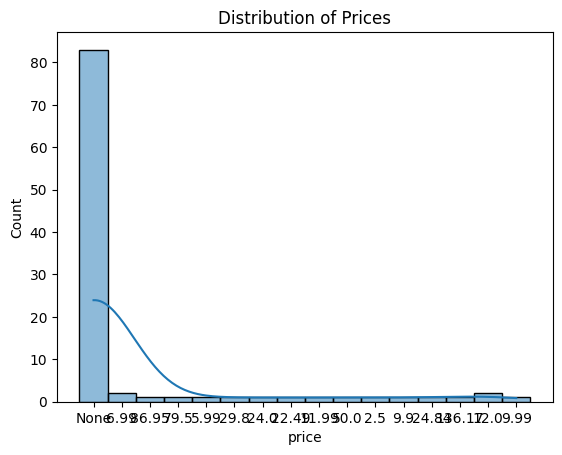

In [23]:
# =========================================================
# 6.1 HISTOGRAM
# =========================================================

sns.histplot(top_products_df["price"], kde=True)
plt.title("Distribution of Prices")
plt.show()

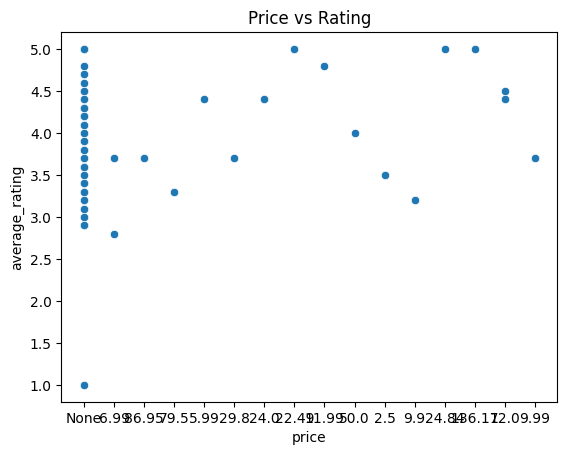

In [24]:
# =========================================================
# 6.2 SCATTER PLOT
# =========================================================

sns.scatterplot(
    data=top_products_df,
    x="price",
    y="average_rating"
)
plt.title("Price vs Rating")
plt.show()

In [25]:
# =========================================================
# 6.3 FILTER HIGH RATED PRODUCTS
# =========================================================

highly_rated_products_df = top_products_df[
    top_products_df["average_rating"] >= 4.7
].sort_values(by="average_rating", ascending=False)

highly_rated_products_df.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
34,All Beauty,DOVE Pro Age Neck & Chest Beauty Serum 3.3oz (Quantity:3),5.0,4,"[Smoothes the appearance of fine lines and wrinkles and improve surface cell renewal, Contains specially selected oils, Makes a real difference in the appearance of you skin's condition]",[Dove Pro-Age Neck & Chest Beauty Serum makes a real difference in the appearance of you skin's condition. It contains specially selected oils to smooth the appearance of fine lines and wrinkles and improve surface cell renewal.],None,"{'hi_res': [None], 'large': ['https://m.media-amazon.com/images/I/31pHPpGS0GL.jpg'], 'thumb': ['https://m.media-amazon.com/images/I/31pHPpGS0GL._SS40_.jpg'], 'variant': ['MAIN']}","{'title': [], 'url': [], 'user_id': []}",Co-t ARBrend,[],"{""Package Dimensions"": ""6.9 x 5.2 x 1.8 inches; 14.4 Ounces"", ""Manufacturer"": ""ARBrend""}",B0017WUID4,None,None,None
32,All Beauty,"Enjoy VOLUMIZING ELIXIR, Style (with Sleek Steel Pin Tail Comb) (8.8 oz)",5.0,1,"[includes a Sleek Steel Pin Tail Comb for easy styling and separation of hair!, This formula styles effortlessly, adding density and texture to fine hair. Gives hair incredible body with long lasting hold., DIRECTIONS FOR USE: On clean damp hair, squeeze a small amount into hands and emulsify, Apply to hair and style as desired., For maximum volume, be sure to apply to the root of the hair and comb through the ends.]","[includes a Sleek Steel Pin Tail Comb for easy styling and separation of hair! This formula styles effortlessly, adding density and texture to fine hair. Gives hair incredible body with long lasting hold. DIRECTIONS FOR USE: On clean damp hair, squeeze a small amount into hands and emulsify. Apply to hair and style as desired. For maximum volume, be sure to apply to the root of the hair and comb through the ends.]",22.49,"{'hi_res': ['https://m.media-amazon.com/images/I/712OdaB6xaL._SL1304_.jpg'], 'large': ['https://m.media-amazon.com/images/I/41D+LJwhpFL.jpg'], 'thumb': ['https://m.media-amazon.com/images/I/41D+LJwhpFL._SS40_.jpg'], 'variant': ['MAIN']}","{'title': [], 'url': [], 'user_id': []}",Enjoy Hair Care Products,[],"{""Is Discontinued By Manufacturer"": ""No"", ""Package Dimensions"": ""8 x 2.2 x 1.8 inches; 8.8 Ounces"", ""UPC"": ""600190915155"", ""Manufacturer"": ""Enjoy Hair Care Products""}",B07DRZLZQQ,None,None,None
93,All Beauty,reskin TS Propolis Serum Even Skin-tone Moisture Care,5.0,1,[],[],None,"{'hi_res': ['https://m.media-amazon.com/images/I/514srN9dXcL._SL1001_.jpg', 'https://m.media-amazon.com/images/I/519kJVIwHOL._SL1001_.jpg', 'https://m.media-amazon.com/images/I/61OlfJaaATL._SL1001_.jpg'], 'large': ['https://m.media-amazon.com/images/I/315TcCiNbbL.jpg', 'https://m.media-amazon.com/images/I/41Deo5RmXhL.jpg', 'https://m.media-amazon.com/images/I/41u5q7-GQLL.jpg'], 'thumb': ['https://m.media-amazon.com/images/I/315TcCiNbbL._SS40_.jpg', 'https://m.media-amazon.com/images/I/41Deo5RmXhL._SS40_.jpg', 'https://m.media-amazon.com/images/I/41u5q7-GQLL._SS40_.jpg'], 'variant': ['MAIN', 'PT01', 'PT02']}","{'title': [], 'url': [], 'user_id': []}",None,[],"{""Package Dimensions"": ""4.8 x 1.3 x 1.3 inches; 1.6 Ounces""}",B0177RLJ1W,None,None,None
91,All Beauty,Remington R7130XLP Men's Shaver,5.0,1,"[High quality remington cord/cordless, 110/220, LCD, Energy star certified, Sleek and portable design]","[High quality remington shaver, men's, washable. High quality remington cord/cordless, 110/220, LCD. Energy star certified.]",None,"{'hi_res': [None], 'large': ['https://m.media-amazon.com/images/I/41jXrf9ywjL.jpg'], 'thumb': ['https://m.media-amazon.com/images/I/41jXrf9ywjL._SS40_.jpg'], 'variant': ['MAIN']}","{'title': [], 'url': [], 'user_id': []}",Remington,[],"{""Product Dimensions"": ""7 x 3 x 4 inches; 1.4 Pounds"", ""Item model number"": ""R7130XLP"", ""Department"": ""Shaving and Hair Removal"

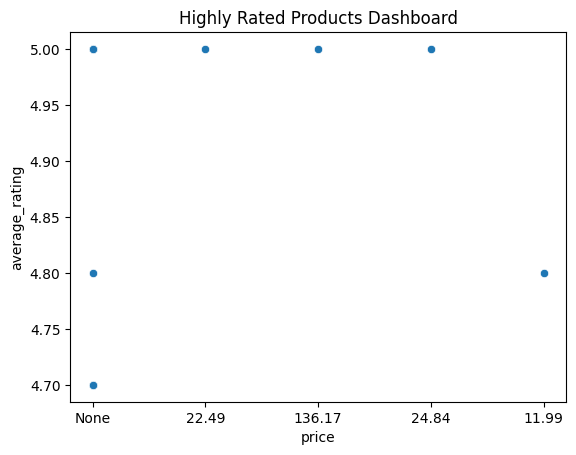

In [26]:
# =========================================================
# 6.4 DASHBOARD
# =========================================================

sns.scatterplot(
    data=highly_rated_products_df,
    x="price",
    y="average_rating"
)
plt.title("Highly Rated Products Dashboard")
plt.show()